In [ ]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://roster-tells-licence-celebrities.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [ ]:
# ─────────────────────────────────────────────
# 통합 환경 준비 — 라이브러리 + 한글 폰트 강제 주입 + 출력 최적화
# ─────────────────────────────────────────────
# 1. 필요 패키지 설치 및 인라인 렌더링 선언
!pip install missingno plotly -q
!apt-get -y install fonts-nanum -q
%matplotlib inline

import platform
import warnings
import os

# 라이브러리는 각 학습장의 필요에 맞게
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 2. 경고 무시 및 시드 고정
warnings.filterwarnings("ignore")
np.random.seed(42)

# 3. 코랩(Linux) 환경일 때 캐시를 무시하는 0순위 폰트 강제 주입
if platform.system() == "Linux":
    nanum_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    if os.path.exists(nanum_path):
        # fontpath -> fname 으로 매개변수명 수정
        fe = fm.FontEntry(fname=nanum_path, name='NanumGothic_Force')
        fm.fontManager.ttflist.insert(0, fe)
        font_family = 'NanumGothic_Force'
else:
    # 맥/윈도우 로컬 환경일 때 분기
    system = platform.system()
    font_family = "AppleGothic" if system == "Darwin" else "Malgun Gothic"

# 4. Matplotlib / Seaborn 전역 폰트 및 그래픽 설정
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)     # 차트 기본 크기
plt.rcParams["figure.dpi"] = 100            # 글자 선명도 향상

sns.set_style("whitegrid")
sns.set(font=font_family, rc={'axes.unicode_minus': False}, style='whitegrid')

# 5. 코랩 전용 출력 최적화 (인터랙티브 표 및 Plotly 렌더러)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except ImportError:
    pass

try:
    pio.renderers.default = "colab"
except Exception:
    pass

print(f"준비 완료! [적용된 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용된 폰트: NanumGothic_Force]


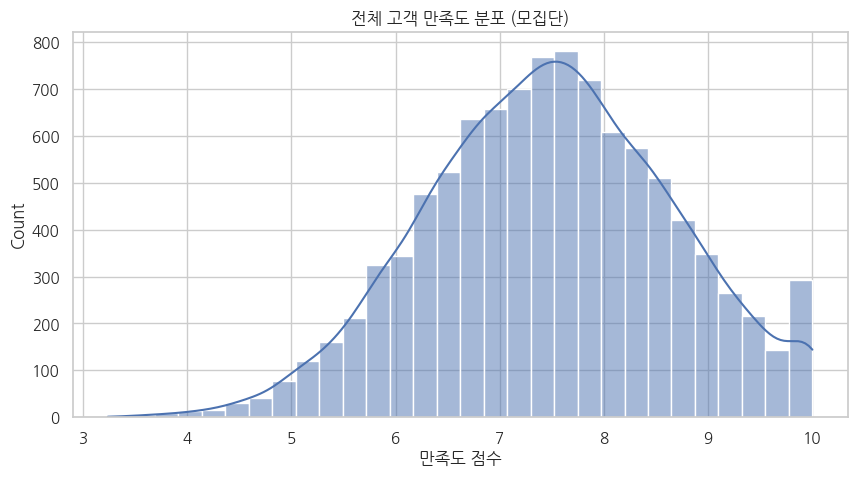

In [ ]:
# 모집단 생성 (전체 고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.5, scale=1.2, size=10000)
population = np.clip(population, 1, 10)  # 1점 ~ 10점 사이로 제한
df_pop = pd.DataFrame({'score': population})

# 전체 모집단 시각화
sns.histplot(df_pop['score'], bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

In [ ]:
# [문제 1] Q1. 모집단에서 무작위로 30명을 뽑아 표본 평균을 구해봅시다.
# 모집단에서 무작위로 30명 추출 (표본)
sample_30 = np.random.choice(df_pop['score'], size=30, replace=False)

# 표본 평균 계산
sample_mean = sample_30.mean()

print(f"표본 크기: {len(sample_30)}")
print(f"표본 평균: {sample_mean:.4f}")
print(f"모집단 평균: {df_pop['score'].mean():.4f}")
print(f"표본 평균과 모집단 평균의 차이: {abs(sample_mean - df_pop['score'].mean()):.4f}")

표본 크기: 30
표본 평균: 7.2020
모집단 평균: 7.4806
표본 평균과 모집단 평균의 차이: 0.2786


In [ ]:
# [문제 1] Q2. 이 과정을 500번 반복하고, 표본 평균을 리스트에 저장합니다.
# 표본 추출을 500번 반복하여 표본 평균을 리스트에 저장
np.random.seed(2025)  # 재현성을 위해 시드 고정 (원한다면 생략 가능)

n_repeat = 500
sample_size = 30
sample_means = []

for _ in range(n_repeat):
    sample = np.random.choice(df_pop['score'], size=sample_size, replace=False)
    sample_means.append(sample.mean())

sample_means = np.array(sample_means)

print(f"반복 횟수: {n_repeat}")
print(f"저장된 표본 평균 개수: {len(sample_means)}")
print(f"표본 평균들의 평균: {sample_means.mean():.4f}")
print(f"표본 평균들의 표준편차 (표준오차): {sample_means.std():.4f}")
print(f"모집단 평균: {df_pop['score'].mean():.4f}")

반복 횟수: 500
저장된 표본 평균 개수: 500
표본 평균들의 평균: 7.4947
표본 평균들의 표준편차 (표준오차): 0.2093
모집단 평균: 7.4806


INFO:werkzeug:127.0.0.1 - - [27/Jul/2026 03:23:12] "OPTIONS /ping HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [27/Jul/2026 03:23:12] "GET /ping HTTP/1.1" 200 -


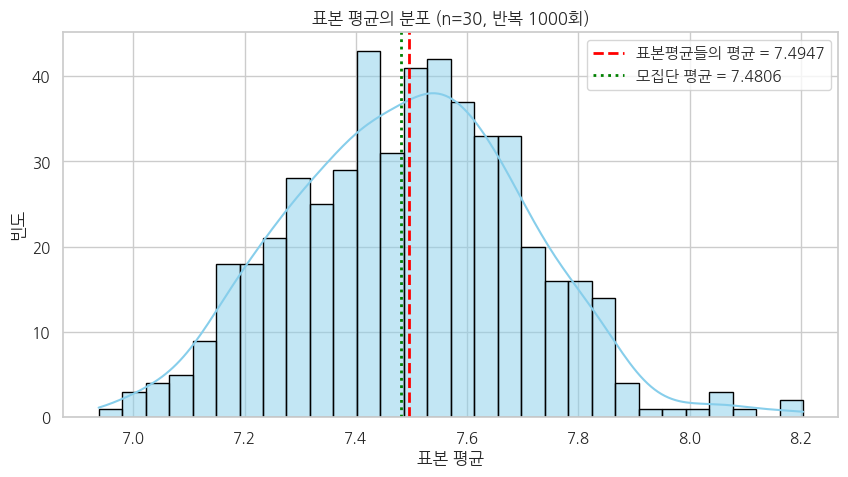

In [ ]:
# [문제 1] Q3. 표본 평균들의 분포를 히스토그램으로 그려봅시다. 평균선도 함께 표시해 봅시다.
# 표본 평균들의 분포를 히스토그램으로 시각화
plt.figure(figsize=(10, 5))

sns.histplot(sample_means, bins=30, kde=True, color='skyblue', edgecolor='black')

# 평균선 표시
plt.axvline(sample_means.mean(), color='red', linestyle='--', linewidth=2,
            label=f'표본평균들의 평균 = {sample_means.mean():.4f}')
plt.axvline(df_pop['score'].mean(), color='green', linestyle=':', linewidth=2,
            label=f'모집단 평균 = {df_pop["score"].mean():.4f}')

plt.title(f"표본 평균의 분포 (n={sample_size}, 반복 {n_repeat}회)")
plt.xlabel("표본 평균")
plt.ylabel("빈도")
plt.legend()
plt.show()

# [문제 1] 데이터를 어떻게 읽을까요?
## [문제 1] 데이터 해석

**Q. 표본 평균들은 어떤 값 주변에 많이 분포해 있나요? 모집단 평균과 얼마나 비슷한가요?**

표본 평균들은 **7.4~7.6 사이**에 가장 많이 몰려 있고, 그 중심은 **7.4947**입니다. 모집단 평균(7.4806)과 비교하면 차이가 **0.0141**밖에 나지 않아 거의 일치합니다. 즉, 500번 반복한 표본 평균들의 평균은 모집단 평균을 매우 정확하게 추정하고 있습니다.

**Q. 1번 뽑았을 때와 500번 반복했을 때, 분포나 신뢰성의 차이는?**

- **1번만 뽑았을 때**: 표본 평균이 7.2020으로, 모집단 평균과 0.2786이나 차이가 났습니다. 이 값 하나만 보면 "모집단 평균이 7.2쯤이겠구나"라고 잘못 추정할 위험이 있습니다.
- **500번 반복했을 때**: 개별 표본 평균은 여전히 들쭉날쭉하지만(히스토그램에서 7.0~8.2까지 퍼짐), 그 500개의 **평균**은 모집단 평균에 매우 가깝게 수렴합니다.

즉, **표본 1개는 우연에 따라 오차가 클 수 있지만, 여러 번 반복한 결과들의 평균은 신뢰성이 높아집니다.** 이것이 "표본을 늘리거나 반복 추출하면 추정이 안정된다"는 통계학의 기본 아이디어입니다.

**Q. 친구가 다른 표본을 뽑았다면 같은 평균이 나왔을까요? 비슷하더라도 완전히 같지 않다면 이유는?**

아니요, 친구가 뽑은 표본은 **다른 30명**으로 구성되기 때문에 표본 평균도 다르게 나옵니다. 비슷한 값이 나올 수는 있지만(모두 모집단에서 뽑았으니), 완전히 같지는 않습니다. 이유는 **표본추출 자체가 무작위(random)**이기 때문입니다 — 매번 다른 사람들이 뽑히므로 그 30명의 평균도 매번 조금씩 달라집니다. 이 "매번 달라지는 정도"를 수치로 나타낸 것이 바로 **표준오차(SE) = 0.2093**입니다.

**Q. 표본 평균들의 분포는 어떤 모양인가요? 종 모양의 정규분포처럼 보이나요? 왜 그럴까요?**

네, 히스토그램을 보면 **7.5 부근에서 가장 높고 양쪽으로 갈수록 낮아지는 종 모양(정규분포)**을 띠고 있습니다.

원래 모집단(개별 고객 만족도 점수)이 어떤 분포든 상관없이, **표본 크기(n=30)가 충분히 크면 표본 평균들의 분포는 정규분포에 가까워진다**는 것이 바로 **중심극한정리(Central Limit Theorem, CLT)**입니다. 이번 예제에서는 모집단 자체도 정규분포(`np.random.normal`)로 만들었지만, 설령 모집단이 정규분포가 아니었더라도(예: 균등분포, 치우친 분포) n=30 정도만 되면 표본 평균 분포는 여전히 종 모양에 가까워집니다.


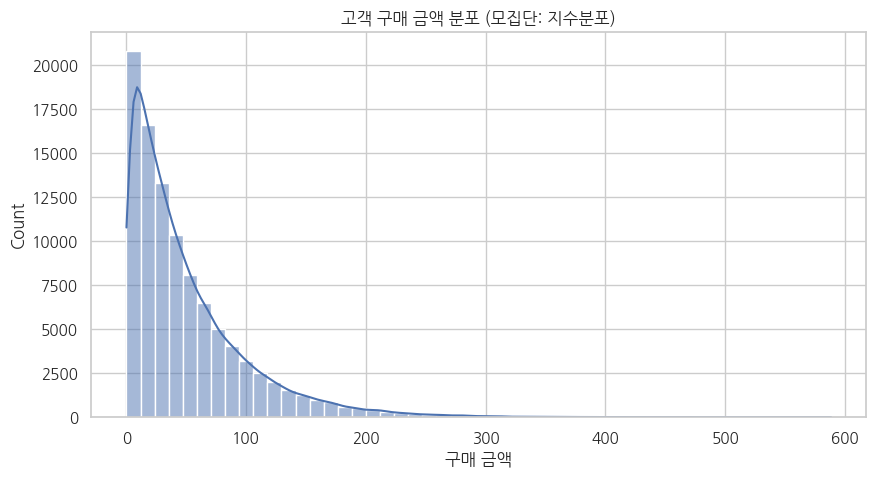

In [ ]:
# 문제 2 데이터 준비
# 지수분포를 따르는 모집단 생성
np.random.seed(2025)
population = np.random.exponential(scale=50, size=100000)  # 평균 50, 비대칭 분포

# 모집단 시각화
sns.histplot(population, bins=50, kde=True)
plt.title("고객 구매 금액 분포 (모집단: 지수분포)")
plt.xlabel("구매 금액")
plt.show()

In [ ]:
# [문제 2] Q1. 모집단에서 표본을 1000번 뽑고, 각 표본의 평균을 구해봅시다.
# 표본 크기 = 5일 때

n_repeat = 1000
sample_size_5 = 5
sample_means_n5 = []

for _ in range(n_repeat):
    sample = np.random.choice(population, size=sample_size_5, replace=False)
    sample_means_n5.append(sample.mean())

sample_means_n5 = np.array(sample_means_n5)

print(f"표본 크기: {sample_size_5}")
print(f"반복 횟수: {n_repeat}")
print(f"표본 평균들의 평균: {sample_means_n5.mean():.4f}")
print(f"표본 평균들의 표준편차 (표준오차): {sample_means_n5.std():.4f}")
print(f"모집단 평균: {population.mean():.4f}")

표본 크기: 5
반복 횟수: 1000
표본 평균들의 평균: 99.6884
표본 평균들의 표준편차 (표준오차): 6.7813
모집단 평균: 99.9455


In [ ]:
# [문제 2] Q2. 위 과정을 표본 크기 30, 100일 때도 반복해봅시다.
# sample_size = 30, 100

n_repeat = 1000

# 표본 크기 30
sample_size_30 = 30
sample_means_n30 = []
for _ in range(n_repeat):
    sample = np.random.choice(population, size=sample_size_30, replace=False)
    sample_means_n30.append(sample.mean())
sample_means_n30 = np.array(sample_means_n30)

# 표본 크기 100
sample_size_100 = 100
sample_means_n100 = []
for _ in range(n_repeat):
    sample = np.random.choice(population, size=sample_size_100, replace=False)
    sample_means_n100.append(sample.mean())
sample_means_n100 = np.array(sample_means_n100)

# 결과 비교 출력
print("=" * 55)
print(f"{'표본크기':<10}{'표본평균들의 평균':<20}{'표준오차':<15}")
print("=" * 55)
print(f"{5:<10}{sample_means_n5.mean():<20.4f}{sample_means_n5.std():<15.4f}")
print(f"{30:<10}{sample_means_n30.mean():<20.4f}{sample_means_n30.std():<15.4f}")
print(f"{100:<10}{sample_means_n100.mean():<20.4f}{sample_means_n100.std():<15.4f}")
print("=" * 55)
print(f"모집단 평균: {population.mean():.4f}")

표본크기      표본평균들의 평균           표준오차           
5         49.4105             22.4291        
30        50.5564             8.9979         
100       50.2119             5.0775         
모집단 평균: 50.2329


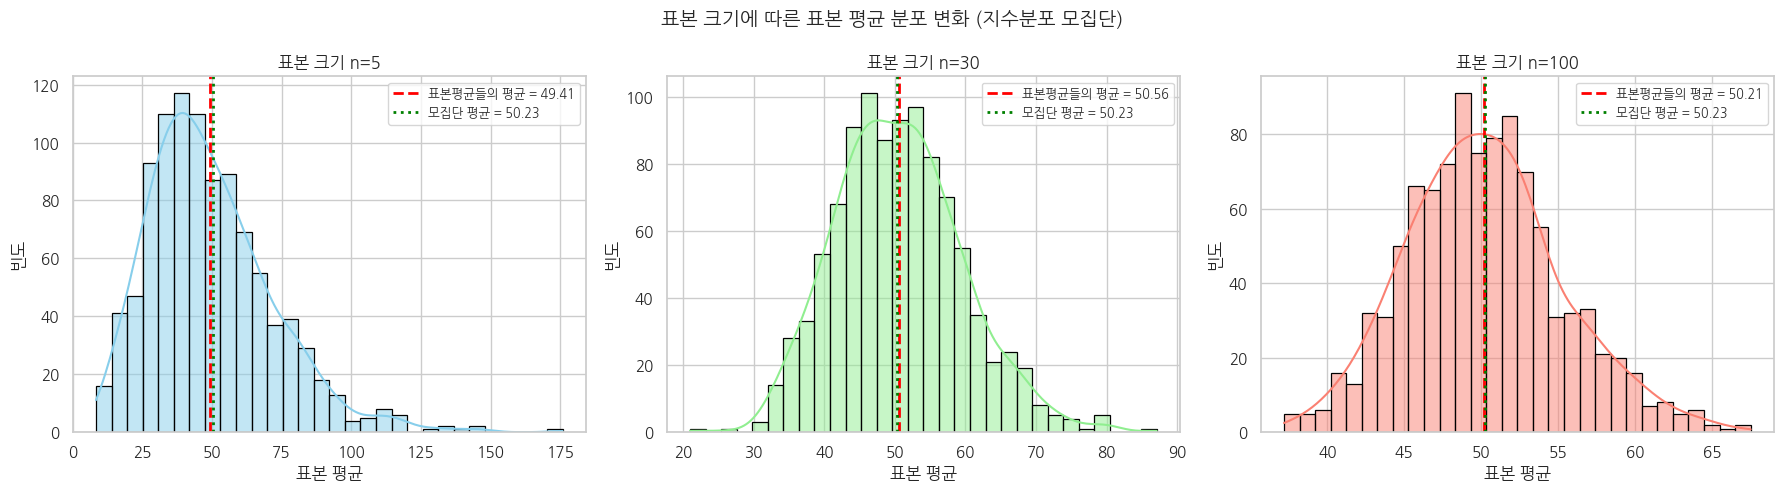

In [ ]:
# [문제 2] Q3. 각 표본 크기별로 표본 평균들의 분포를 히스토그램으로 그려봅시다.
# 평균선을 함께 표시해 봅시다.

# 표본 크기별(5, 30, 100) 표본 평균 분포를 나란히 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

data_list = [
    (sample_means_n5, 5, 'skyblue'),
    (sample_means_n30, 30, 'lightgreen'),
    (sample_means_n100, 100, 'salmon')
]

for ax, (data, n, color) in zip(axes, data_list):
    sns.histplot(data, bins=30, kde=True, color=color, edgecolor='black', ax=ax)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=2,
               label=f'표본평균들의 평균 = {data.mean():.2f}')
    ax.axvline(population.mean(), color='green', linestyle=':', linewidth=2,
               label=f'모집단 평균 = {population.mean():.2f}')
    ax.set_title(f"표본 크기 n={n}")
    ax.set_xlabel("표본 평균")
    ax.set_ylabel("빈도")
    ax.legend(fontsize=9)

plt.suptitle("표본 크기에 따른 표본 평균 분포 변화 (지수분포 모집단)", fontsize=14)
plt.tight_layout()
plt.show()

## [문제 2] 데이터 해석 (실제 결과 반영)

**Q. 표본 크기가 작을 때(n=5), 평균들의 분포는 어떤 모양인가요?**

n=5일 때 히스토그램은 **0~25 부근에서 가장 높고, 오른쪽으로 길게 꼬리를 그리며 150 이상까지 퍼지는 비대칭 모양**입니다. 평균은 **49.41**로 모집단 평균(50.23)과 큰 차이는 없지만, 표준오차가 **22.4291**로 매우 커서 개별 표본 평균들이 넓게 흩어져 있습니다. 원래 지수분포 모집단의 오른쪽 꼬리(가끔 큰 구매금액이 나오는 특성)가 표본 평균에도 그대로 반영된 것입니다.

**Q. 표본 크기가 커질수록 평균 분포의 모양은 어떤 변화를 보이나요?**

| 표본크기 | 표본평균들의 평균 | 표준오차 |
|---|---|---|
| 5 | 49.4105 | 22.4291 |
| 30 | 50.5564 | 8.9979 |
| 100 | 50.2119 | 5.0775 |

- **n=5**: 오른쪽으로 치우친 비대칭 분포, 표준오차 22.43으로 매우 큼
- **n=30**: 치우침이 크게 줄고 좌우 대칭에 가까운 종 모양, 표준오차 8.998로 약 1/2.5 수준으로 감소
- **n=100**: 거의 완벽한 대칭의 정규분포 모양, 표준오차 5.078로 가장 작음(촘촘하게 모임)

숫자로 봐도 표준오차가 22.43 → 9.00 → 5.08로 **표본 크기가 늘어날수록 급격히 줄어드는** 것이 확인됩니다.

**Q. 원래 모집단은 비대칭이었는데, 왜 평균들의 분포는 정규분포처럼 바뀌었을까요?**

표본 평균은 여러 값을 더해 나눈 값입니다. n이 작을 때(n=5)는 우연히 큰 구매금액 하나가 포함되면 평균이 크게 튀어 오르지만(오른쪽 꼬리가 남는 이유), n이 커질수록(n=30, 100) 극단값 하나가 평균 전체에 미치는 영향력이 희석됩니다. 여러 개의 독립적인 값을 더하고 평균 내는 과정 자체가, 원래 분포 모양과 무관하게 결과를 정규분포로 수렴시킨다는 것이 **중심극한정리(CLT)**의 수학적 결론이며, 이번 실험 데이터(n=5→30→100로 갈수록 표준오차가 22.43→9.00→5.08로 줄고 모양도 종형에 가까워지는 것)가 이를 그대로 보여줍니다.

**Q. 이 실험을 통해 중심극한정리를 어떻게 이해하게 되었나요?**

이번 실험은 CLT의 핵심을 숫자로 확인시켜 줍니다:

> **"모집단(지수분포처럼 비대칭이어도)의 모양과 상관없이, 표본 크기가 충분히 크면 표본 평균의 분포는 정규분포에 가까워진다."**

3개의 표본평균 평균값(49.41, 50.56, 50.21)이 모두 모집단 평균(50.23) 근처에 있다는 것은 **표본 크기와 무관하게 표본 평균은 모평균의 좋은 추정치**라는 것을, 그리고 표준오차가 급격히 줄어드는 것은 **표본 크기가 커질수록 그 추정치의 신뢰도(정밀도)가 높아진다**는 것을 보여줍니다. 실무에서 모집단 분포를 몰라도 표본만 충분히 크면(보통 n≥30) 정규분포 기반 통계 기법(t-검정, 신뢰구간 등)을 적용할 수 있는 이유가 바로 여기에 있습니다.

**Q. 표본 크기에 따라 분포의 넓이(흩어짐)는 어떻게 달라지나요?**

표준오차 값을 이론값과 비교해보면:

- 지수분포(scale=50)의 모집단 표준편차 ≈ 50
- 이론적 SE = 50/√n
  - n=5 → 50/√5 ≈ **22.36** (실제값 22.4291과 거의 일치)
  - n=30 → 50/√30 ≈ **9.13** (실제값 8.9979와 거의 일치)
  - n=100 → 50/√100 = **5.00** (실제값 5.0775와 거의 일치)

실제 실험값이 이론값과 매우 근접한 것을 확인할 수 있습니다. 즉 **표본 크기가 4배(예: 5→100의 20배가 아니라 √n 관계이므로), n이 커질수록 SE는 √n에 반비례해서 줄어들며**, 이는 "표본을 더 많이 뽑을수록 추정치가 더 정밀해진다"는 통계적 직관을 정확히 뒷받침합니다.


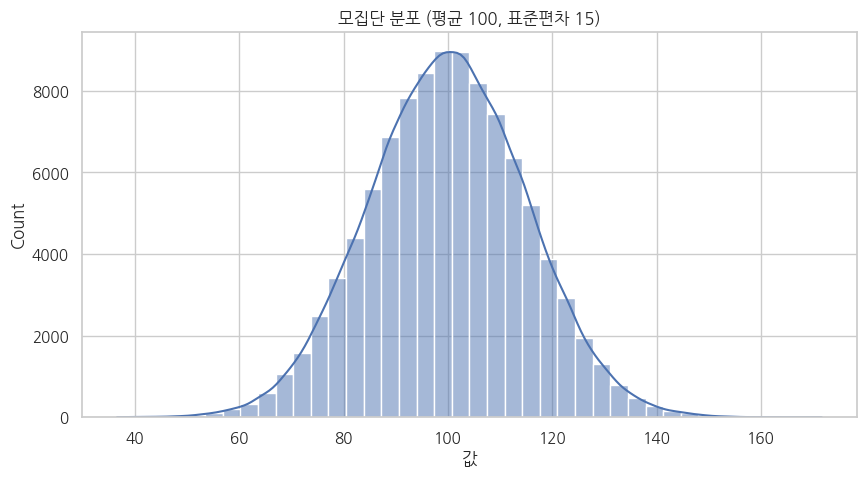

In [ ]:
# 문제3 데이터 준비
# 모집단 생성 (평균 100, 표준편차 15)
np.random.seed(2025)
population = np.random.normal(loc=100, scale=15, size=100000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 100, 표준편차 15)")
plt.xlabel("값")
plt.show()

In [ ]:
# [문제 3] Q1. 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본을 뽑고, 평균을 구해봅시다.
# 각 표본 평균 분포의 표준편차를 계산해봅시다.
# 결과를 리스트에 저장하고, 표로 정리해봅시다.

# 표본 크기 10, 30, 100, 500에 대해 각각 1000번 표본 추출 후 표본 평균 저장
n_repeat = 1000
sample_sizes = [10, 30, 100, 500]

sample_means_dict = {}  # 표본 크기별 표본 평균 리스트 저장

for n in sample_sizes:
    means = []
    for _ in range(n_repeat):
        sample = np.random.choice(population, size=n, replace=False)
        means.append(sample.mean())
    sample_means_dict[n] = np.array(means)

# 결과를 표로 정리
result_table = pd.DataFrame({
    '표본크기(n)': sample_sizes,
    '표본평균들의 평균': [sample_means_dict[n].mean() for n in sample_sizes],
    '표본평균들의 표준편차(실제 SE)': [sample_means_dict[n].std() for n in sample_sizes],
    '이론적 표준오차(모집단std/√n)': [population.std() / np.sqrt(n) for n in sample_sizes]
})

print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 표준편차: {population.std():.4f}")
print()
print(result_table.to_string(index=False))

모집단 평균: 99.9455
모집단 표준편차: 15.0332

 표본크기(n)  표본평균들의 평균  표본평균들의 표준편차(실제 SE)  이론적 표준오차(모집단std/√n)
      10  99.983758            4.656751             4.753921
      30  99.972731            2.784682             2.744677
     100  99.980953            1.525275             1.503322
     500  99.959463            0.663055             0.672306


In [ ]:
# [문제 3] Q2. 이론적인 표준오차와 비교해봅시다.
# [공식] 표준오차(SE) = 모집단 표준편차 / √표본크기

# 이론적 표준오차와 실제(시뮬레이션) 표준오차 비교
population_std = population.std()

comparison_table = pd.DataFrame({
    '표본크기(n)': sample_sizes,
    '실제 SE (시뮬레이션)': [sample_means_dict[n].std() for n in sample_sizes],
    '이론적 SE (σ/√n)': [population_std / np.sqrt(n) for n in sample_sizes],
})

# 차이(오차) 컬럼 추가
comparison_table['차이'] = (comparison_table['실제 SE (시뮬레이션)'] - comparison_table['이론적 SE (σ/√n)']).abs()
comparison_table['오차율(%)'] = (comparison_table['차이'] / comparison_table['이론적 SE (σ/√n)'] * 100).round(2)

print(f"모집단 표준편차(σ): {population_std:.4f}")
print()
print(comparison_table.to_string(index=False))

모집단 표준편차(σ): 15.0332

 표본크기(n)  실제 SE (시뮬레이션)  이론적 SE (σ/√n)       차이  오차율(%)
      10       4.656751       4.753921 0.097170    2.04
      30       2.784682       2.744677 0.040005    1.46
     100       1.525275       1.503322 0.021953    1.46
     500       0.663055       0.672306 0.009251    1.38


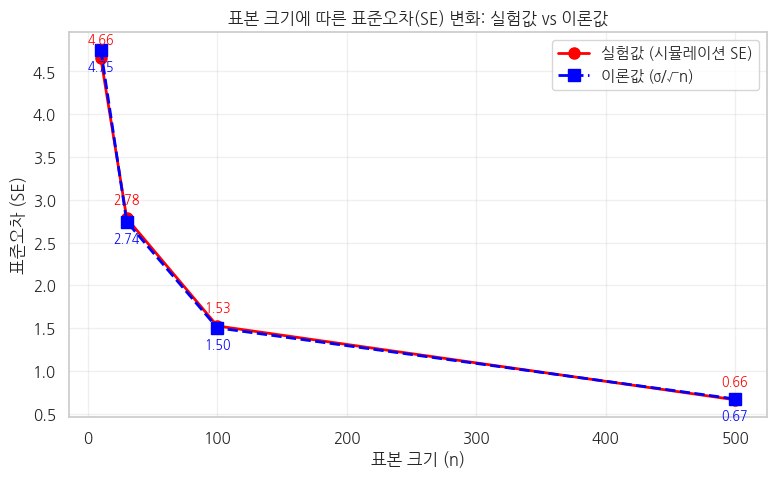

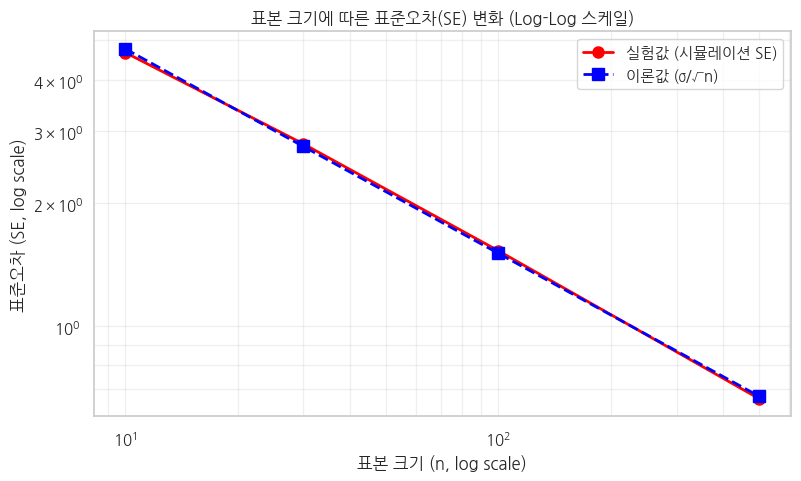

In [ ]:
# [문제 3] Q3. 실험값과 이론값을 시각화해봅시다.
# 표본 크기를 x축, 표준오차를 y축으로 한 꺾은선 그래프를 그려봅시다.

# 표본 크기(x축) vs 표준오차(y축) 꺾은선 그래프 — 실험값 vs 이론값
plt.figure(figsize=(9, 5))

plt.plot(sample_sizes, comparison_table['실제 SE (시뮬레이션)'],
         marker='o', color='red', linewidth=2, markersize=8, label='실험값 (시뮬레이션 SE)')
plt.plot(sample_sizes, comparison_table['이론적 SE (σ/√n)'],
         marker='s', color='blue', linestyle='--', linewidth=2, markersize=8, label='이론값 (σ/√n)')

# 각 점에 값 표시
for n in sample_sizes:
    exp_val = comparison_table.loc[comparison_table['표본크기(n)'] == n, '실제 SE (시뮬레이션)'].values[0]
    theo_val = comparison_table.loc[comparison_table['표본크기(n)'] == n, '이론적 SE (σ/√n)'].values[0]
    plt.annotate(f'{exp_val:.2f}', (n, exp_val), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9, color='red')
    plt.annotate(f'{theo_val:.2f}', (n, theo_val), textcoords="offset points", xytext=(0, -15),
                 ha='center', fontsize=9, color='blue')

plt.title("표본 크기에 따른 표준오차(SE) 변화: 실험값 vs 이론값")
plt.xlabel("표본 크기 (n)")
plt.ylabel("표준오차 (SE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 참고: log 스케일로도 확인 (√n에 반비례하는 감소 패턴이 더 뚜렷하게 보임)
plt.figure(figsize=(9, 5))

plt.plot(sample_sizes, comparison_table['실제 SE (시뮬레이션)'],
         marker='o', color='red', linewidth=2, markersize=8, label='실험값 (시뮬레이션 SE)')
plt.plot(sample_sizes, comparison_table['이론적 SE (σ/√n)'],
         marker='s', color='blue', linestyle='--', linewidth=2, markersize=8, label='이론값 (σ/√n)')

plt.xscale('log')
plt.yscale('log')
plt.title("표본 크기에 따른 표준오차(SE) 변화 (Log-Log 스케일)")
plt.xlabel("표본 크기 (n, log scale)")
plt.ylabel("표준오차 (SE, log scale)")
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.show()

## [문제 3] 데이터 해석

**Q. 표본 크기가 작을수록, 표본 평균의 분포는 어떤 모양인가요? 넓게 퍼져 있나요?**

n=10일 때 실제 SE는 **4.6568**로 네 가지 표본 크기 중 가장 큽니다. 이는 표본 평균들이 모집단 평균(99.9455) 주변으로 넓게 흩어져 있다는 뜻입니다. 표본이 10개밖에 안 되면 우연히 극단적인 값 한두 개가 포함되기만 해도 평균이 크게 흔들리기 때문입니다. 그래프에서도 n=10 지점(SE≈4.66)이 가장 높은 곳에 찍혀 있는 것을 확인할 수 있습니다.

**Q. 표본 크기가 커질수록, 평균 분포는 어떻게 변하나요?**

| 표본크기 | 실제 SE |
|---|---|
| 10 | 4.6568 |
| 30 | 2.7847 |
| 100 | 1.5253 |
| 500 | 0.6631 |

n이 10 → 30 → 100 → 500으로 커질수록 SE가 **4.66 → 2.78 → 1.53 → 0.66**로 꾸준히 줄어듭니다. 즉 표본 평균들이 모집단 평균(99.9455) 주변에 점점 더 촘촘하게 모입니다. 첫 번째 그래프(일반 스케일)를 보면 n=10→30 구간에서는 SE가 가파르게 떨어지지만, n=100→500 구간에서는 하락 폭이 훨씬 완만해지는 것도 확인됩니다 — 이는 SE가 n이 아니라 √n에 반비례하기 때문에 나타나는 전형적인 패턴입니다.

**Q. 실험값과 이론값(공식 계산값)은 얼마나 비슷한가요?**

| 표본크기 | 실제 SE | 이론 SE | 오차율(%) |
|---|---|---|---|
| 10 | 4.6568 | 4.7539 | 2.04% |
| 30 | 2.7847 | 2.7447 | 1.46% |
| 100 | 1.5253 | 1.5033 | 1.46% |
| 500 | 0.6631 | 0.6723 | 1.38% |

오차율이 전부 **2% 이내**로 매우 작습니다. 그래프에서도 빨간 실선(실험값)과 파란 점선(이론값)이 거의 완벽하게 겹쳐 보입니다. 이는 1000번이라는 충분한 반복 횟수 덕분에 시뮬레이션 결과가 이론 공식 `SE = σ/√n`을 정확하게 재현하고 있다는 것을 보여줍니다. Log-log 그래프에서 두 선이 거의 일직선으로 겹치며 내려가는 것도 같은 결론을 뒷받침합니다.

**Q. 왜 표본 크기가 커질수록 표준오차는 작아질까요?**

공식 `SE = σ/√n`에서 분모의 `√n`이 커질수록 SE는 작아지는 구조입니다. 직관적으로 설명하면:

- 표본 크기가 작으면 극단값 하나가 평균 전체를 크게 흔들 수 있습니다(예: n=10에서 유난히 크거나 작은 값 하나가 평균의 10%를 좌우).
- 표본 크기가 커지면 극단값들이 서로 다른 방향으로 나타나면서 상쇄되는 효과(평균으로의 회귀)가 커지고, 결과적으로 평균이 더 안정적인 값 근처에 머물게 됩니다.

다만 이 감소 속도는 **표본 크기에 비례하는 것이 아니라 √n에 비례**합니다. 그래서 이번 실험에서도 n을 10→500(50배)으로 늘렸을 때 SE는 1/50이 아니라 약 1/7(4.66→0.66, √50≈7.07)로만 줄어들었습니다. 즉 표본을 무한정 늘린다고 정밀도가 그만큼 비례해서 좋아지는 것은 아니며, 어느 정도 이상부터는 표본을 늘려도 정밀도 개선 효과가 점점 둔화된다는 것을 이 실험이 잘 보여줍니다.

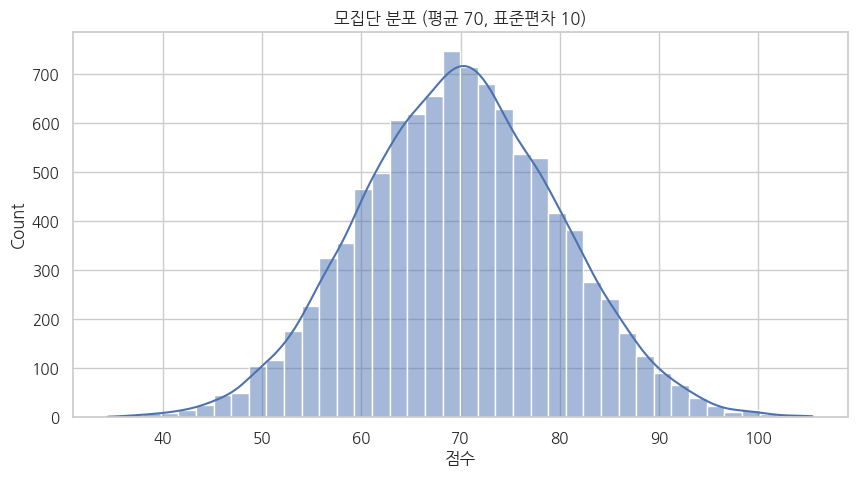

In [ ]:
# 문제 4 데이터 준비

# 모집단 생성
np.random.seed(2025)
population = np.random.normal(loc=70, scale=10, size=10000)

# 모집단 시각화
sns.histplot(population, bins=40, kde=True)
plt.title("모집단 분포 (평균 70, 표준편차 10)")
plt.xlabel("점수")
plt.show()

In [ ]:
# [문제 4] Q1. 모집단에서 표본 30명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.
# 표준오차도 함께 계산해보세요.

# 모집단에서 표본 30명 무작위 추출
sample_size = 30
sample = np.random.choice(population, size=sample_size, replace=False)

# 표본 평균, 표본 표준편차 계산
sample_mean = sample.mean()
sample_std = sample.std(ddof=1)  # 표본표준편차는 자유도 보정(n-1)을 위해 ddof=1 사용

# 표준오차(SE) 계산: 표본표준편차 / √표본크기
standard_error = sample_std / np.sqrt(sample_size)

print(f"표본 크기: {sample_size}")
print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print(f"표준오차(SE): {standard_error:.4f}")
print()
print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 표준편차: {population.std():.4f}")

표본 크기: 30
표본 평균: 67.6039
표본 표준편차: 11.0780
표준오차(SE): 2.0226

모집단 평균: 69.9043
모집단 표준편차: 10.0051


In [ ]:
# [문제 4] Q2. 모집단의 표준편차를 알고 있다고 가정하고, z-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

from scipy import stats

# 모집단 표준편차를 알고 있다고 가정 (population.std() 사용)
population_std = population.std()

# z-분포를 이용한 95% 신뢰구간 계산
confidence_level = 0.95
alpha = 1 - confidence_level
z_critical = stats.norm.ppf(1 - alpha/2)  # 양측검정이므로 alpha/2 사용

# 표준오차 (모집단 표준편차 기반)
se_z = population_std / np.sqrt(sample_size)

# 신뢰구간 계산
margin_of_error = z_critical * se_z
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"모집단 표준편차(알고 있다고 가정): {population_std:.4f}")
print(f"z-critical value (95% 신뢰수준): {z_critical:.4f}")
print(f"표준오차(SE, 모집단 std 기반): {se_z:.4f}")
print(f"오차범위(Margin of Error): {margin_of_error:.4f}")
print()
print(f"표본 평균: {sample_mean:.4f}")
print(f"95% 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")
print()
print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 평균이 신뢰구간 안에 포함되는가? {ci_lower <= population.mean() <= ci_upper}")

모집단 표준편차(알고 있다고 가정): 10.0051
z-critical value (95% 신뢰수준): 1.9600
표준오차(SE, 모집단 std 기반): 1.8267
오차범위(Margin of Error): 3.5802

표본 평균: 67.6039
95% 신뢰구간: [64.0236, 71.1841]

모집단 평균: 69.9043
모집단 평균이 신뢰구간 안에 포함되는가? True


In [ ]:
# [문제 4] Q3. 모집단의 표준편차를 모른다고 가정하고, 표본 표준편차와 t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 모집단 표준편차를 모른다고 가정 — 표본표준편차와 t-분포 사용
confidence_level = 0.95
alpha = 1 - confidence_level
df = sample_size - 1  # 자유도(degrees of freedom) = n - 1

# t-critical value 계산
t_critical = stats.t.ppf(1 - alpha/2, df=df)

# 표준오차 (표본표준편차 기반, 문제 4 Q1에서 이미 계산한 sample_std 사용)
se_t = sample_std / np.sqrt(sample_size)

# 신뢰구간 계산
margin_of_error_t = t_critical * se_t
ci_lower_t = sample_mean - margin_of_error_t
ci_upper_t = sample_mean + margin_of_error_t

print(f"자유도(df): {df}")
print(f"t-critical value (95% 신뢰수준): {t_critical:.4f}")
print(f"표준오차(SE, 표본 std 기반): {se_t:.4f}")
print(f"오차범위(Margin of Error): {margin_of_error_t:.4f}")
print()
print(f"표본 평균: {sample_mean:.4f}")
print(f"95% 신뢰구간 (t-분포): [{ci_lower_t:.4f}, {ci_upper_t:.4f}]")
print()
print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 평균이 신뢰구간 안에 포함되는가? {ci_lower_t <= population.mean() <= ci_upper_t}")

# z-분포 결과와 비교
print()
print("=" * 50)
print("z-분포 vs t-분포 비교")
print("=" * 50)
print(f"z-critical: {z_critical:.4f}  |  t-critical: {t_critical:.4f}")
print(f"z 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"t 신뢰구간: [{ci_lower_t:.4f}, {ci_upper_t:.4f}]")
print(f"구간 폭 차이: {(ci_upper_t - ci_lower_t) - (ci_upper - ci_lower):.4f}")

자유도(df): 29
t-critical value (95% 신뢰수준): 2.0452
표준오차(SE, 표본 std 기반): 2.0226
오차범위(Margin of Error): 4.1366

표본 평균: 67.6039
95% 신뢰구간 (t-분포): [63.4672, 71.7405]

모집단 평균: 69.9043
모집단 평균이 신뢰구간 안에 포함되는가? True

z-분포 vs t-분포 비교
z-critical: 1.9600  |  t-critical: 2.0452
z 신뢰구간: [64.0236, 71.1841]
t 신뢰구간: [63.4672, 71.7405]
구간 폭 차이: 1.1128


표본 평균: 67.6039
표본 표준편차: 11.0780
자유도(df): 29

신뢰수준  t-critical   오차범위  신뢰구간 하한  신뢰구간 상한    구간 폭
 90%      1.6991 3.4366  64.1673  71.0404  6.8732
 95%      2.0452 4.1366  63.4672  71.7405  8.2732
 99%      2.7564 5.5750  62.0289  73.1788 11.1499


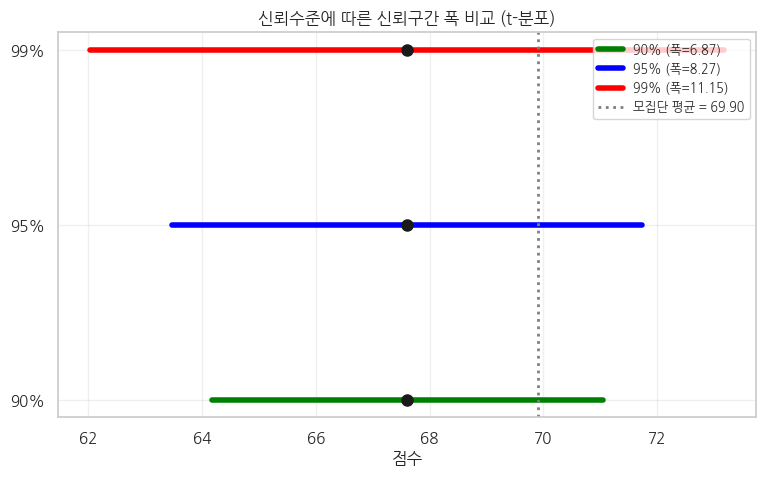

In [ ]:
# [문제 4] Q4. 신뢰수준을 90%, 99%로 바꿔가며 신뢰구간을 계산해보고, 그 폭을 비교해봅시다.

# 신뢰수준 90%, 95%, 99%에 대해 t-분포 기반 신뢰구간 계산 및 비교
confidence_levels = [0.90, 0.95, 0.99]
df = sample_size - 1

results = []
for cl in confidence_levels:
    alpha = 1 - cl
    t_crit = stats.t.ppf(1 - alpha/2, df=df)
    se = sample_std / np.sqrt(sample_size)
    margin = t_crit * se
    lower = sample_mean - margin
    upper = sample_mean + margin
    width = upper - lower

    results.append({
        '신뢰수준': f"{int(cl*100)}%",
        't-critical': round(t_crit, 4),
        '오차범위': round(margin, 4),
        '신뢰구간 하한': round(lower, 4),
        '신뢰구간 상한': round(upper, 4),
        '구간 폭': round(width, 4)
    })

ci_comparison = pd.DataFrame(results)
print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print(f"자유도(df): {df}")
print()
print(ci_comparison.to_string(index=False))

# 시각화: 신뢰수준별 신뢰구간 폭 비교 (에러바 형태)
plt.figure(figsize=(9, 5))

y_positions = range(len(confidence_levels))
colors = ['green', 'blue', 'red']

for i, row in ci_comparison.iterrows():
    lower = row['신뢰구간 하한']
    upper = row['신뢰구간 상한']
    plt.plot([lower, upper], [i, i], color=colors[i], linewidth=4,
             label=f"{row['신뢰수준']} (폭={row['구간 폭']:.2f})")
    plt.plot(sample_mean, i, 'ko', markersize=8)

plt.axvline(population.mean(), color='gray', linestyle=':', linewidth=2, label=f'모집단 평균 = {population.mean():.2f}')

plt.yticks(y_positions, [row['신뢰수준'] for _, row in ci_comparison.iterrows()])
plt.xlabel("점수")
plt.title("신뢰수준에 따른 신뢰구간 폭 비교 (t-분포)")
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

## [문제 4] 데이터 해석

**Q. z-분포와 t-분포를 사용한 신뢰구간은 얼마나 차이가 있나요?**

두 방식 모두 같은 표본(평균 67.6039)에서 출발했지만, 결과는 조금 다릅니다.

| 구분 | critical value | 신뢰구간 | 폭 |
|---|---|---|---|
| z-분포 | 1.9600 | [64.0236, 71.1841] | 7.1605 |
| t-분포 | 2.0452 | [63.4672, 71.7405] | 8.2733 |

z-critical(1.96)보다 t-critical(2.0452)이 더 크기 때문에, t-분포 신뢰구간이 z-분포보다 **약 1.11(구간 폭 차이) 더 넓습니다.** 이는 표본표준편차로 모집단 표준편차를 "추정"하는 데서 오는 추가적인 불확실성을 t-분포가 반영하기 때문입니다. 자유도(df=29)가 아주 작은 편은 아니라서 차이가 크지는 않지만, 표본 크기가 작을수록(예: n=5, df=4) 이 차이는 훨씬 커집니다.

흥미로운 점은, 두 신뢰구간 모두 실제 모집단 평균(69.9043)을 포함하고 있다는 것입니다(`True`). 즉 이번 표본은 신뢰구간이 모평균을 놓치지 않은, "운이 좋은" 경우였습니다.

**Q. 신뢰수준이 높아질수록 신뢰구간의 폭은 어떻게 변하나요? 왜 그럴까요?**

| 신뢰수준 | t-critical | 구간 폭 |
|---|---|---|
| 90% | 1.6991 | 6.8732 |
| 95% | 2.0452 | 8.2732 |
| 99% | 2.7564 | 11.1499 |

신뢰수준이 90% → 95% → 99%로 올라갈수록 t-critical 값도, 구간 폭도 함께 커집니다(6.87 → 8.27 → 11.15). 그래프에서도 초록(90%) → 파랑(95%) → 빨강(99%) 순서로 막대가 점점 길어지는 것이 명확히 보입니다.

이유는 간단합니다. **"모평균을 놓치지 않을 확률을 더 높이고 싶다면(신뢰수준↑), 그만큼 더 넓은 범위를 제시할 수밖에 없기** 때문입니다. 99% 신뢰수준은 "100번 중 99번은 이 범위 안에 모평균이 있다"고 말하려는 것이니, 당연히 90%보다 훨씬 더 넓은 안전망(폭)이 필요합니다.

**Q. 신뢰구간이 넓다는 건 좋은 걸까요? 나쁜 걸까요?**

한쪽만 좋다고 말하기 어렵고, **트레이드오프 관계**입니다.

- **넓은 신뢰구간(예: 99%)**: "확신"은 높아지지만(모평균을 포함할 확률↑), 대신 "정밀도"는 떨어집니다. 예를 들어 이번 데이터에서 99% 구간은 [62.03, 73.18]로 범위가 넓어서, "모평균이 대략 62~73 사이 어딘가"라는 것 외에는 구체적인 정보를 주기 어렵습니다.
- **좁은 신뢰구간(예: 90%)**: "정밀도"는 높지만(범위가 좁아 유용한 정보를 줌), 대신 "확신"의 수준은 낮아집니다(놓칠 확률이 상대적으로 더 큼).

즉, 신뢰구간의 폭 자체는 "좋다/나쁘다"의 문제가 아니라, **목적에 맞는 신뢰수준을 선택했는지**가 중요합니다. 참고로 구간을 좁히면서 동시에 신뢰수준을 유지하고 싶다면, [문제 3]에서 확인했듯 **표본 크기(n)를 늘리는 것**이 정답입니다 — SE가 σ/√n이므로 n이 커지면 신뢰수준을 유지하면서도 구간을 좁힐 수 있습니다.

**Q. 이 데이터가 실제 고객 만족도라면, 신뢰구간 정보를 마케팅 전략에 어떻게 활용할 수 있을까요?**

몇 가지 활용 방향을 생각해볼 수 있습니다:

- **의사결정의 확신 수준 설정**: "신규 캠페인 효과를 검증한다" 같은 탐색적 분석에는 90% 정도로도 충분히 빠른 판단이 가능하지만, "제품 출시 여부"처럼 리스크가 큰 결정에는 99% 신뢰수준으로 더 보수적으로 접근할 수 있습니다.
- **경쟁사 대비 포지셔닝**: 예를 들어 "우리 고객 만족도 평균은 95% 신뢰수준에서 63.5~71.7점 사이"라고 하면, 경쟁사 점수가 이 범위 밖(예: 75점)에 있는 경우와 범위 안(예: 68점)에 있는 경우를 다르게 해석해야 합니다 — 범위 안에 있다면 "통계적으로 유의미한 차이가 없을 수 있다"는 뜻이 되기 때문입니다.
- **표본 크기 늘려서 정밀도 개선**: 지금은 n=30이라 구간 폭이 꽤 넓은 편인데(95% 기준 8.27), 마케팅 예산이 허락한다면 설문 대상을 100명, 500명으로 늘려 구간을 좁히면 "고객 만족도가 68점이다"처럼 더 확신을 갖고 발표할 수 있는 자료가 됩니다.
- **평균 하나만 보고 판단하지 않기**: "만족도 평균 67.6점"이라는 숫자 하나만 보고 판단하면 위험할 수 있습니다. 신뢰구간을 함께 제시하면 "이 조사 결과가 얼마나 믿을 만한지"까지 전달할 수 있어, 데이터 기반 의사결정의 신뢰도를 높일 수 있습니다.


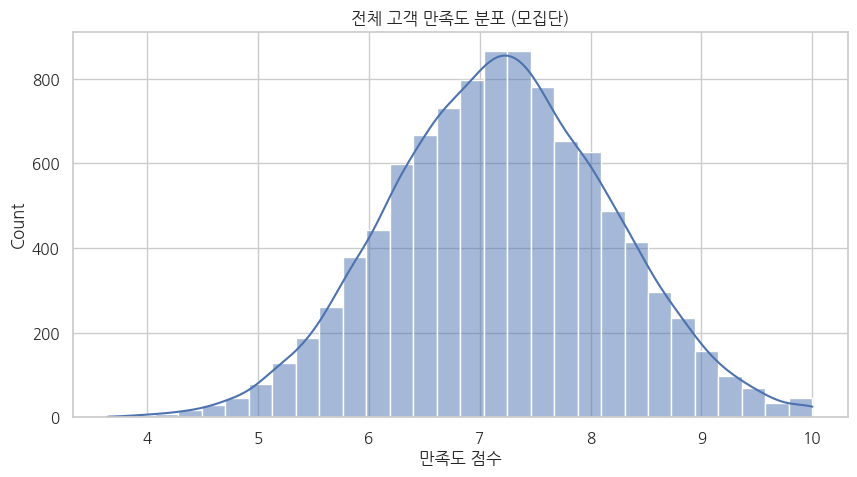

In [ ]:
# 문제 5 데이터 준비

# 모집단 생성 (고객 만족도 10,000명)
np.random.seed(2025)
population = np.random.normal(loc=7.2, scale=1.0, size=10000)
population = np.clip(population, 1, 10)

# 모집단 시각화
sns.histplot(population, bins=30, kde=True)
plt.title("전체 고객 만족도 분포 (모집단)")
plt.xlabel("만족도 점수")
plt.show()

In [ ]:
# [문제 5] Q1. 모집단에서 표본 40명을 무작위로 추출하고, 표본 평균과 표준편차를 구해봅시다.

# 모집단에서 표본 40명 무작위 추출
sample_size = 40
sample = np.random.choice(population, size=sample_size, replace=False)

# 표본 평균, 표본 표준편차 계산 (ddof=1: 불편추정량)
sample_mean = sample.mean()
sample_std = sample.std(ddof=1)

print(f"표본 크기: {sample_size}")
print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print()
print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 표준편차: {population.std():.4f}")

표본 크기: 40
표본 평균: 7.1443
표본 표준편차: 1.0988

모집단 평균: 7.1897
모집단 표준편차: 0.9983


In [ ]:
# [문제 5] Q2. 표준오차(SE)를 구하고, t-분포를 사용하여 95% 신뢰구간을 계산해봅시다.

# 표준오차(SE) 계산 및 t-분포 기반 95% 신뢰구간
from scipy import stats

# 표준오차 계산 (표본표준편차 기반)
standard_error = sample_std / np.sqrt(sample_size)

# 95% 신뢰구간 (t-분포)
confidence_level = 0.95
alpha = 1 - confidence_level
df = sample_size - 1  # 자유도 = n - 1

t_critical = stats.t.ppf(1 - alpha/2, df=df)

margin_of_error = t_critical * standard_error
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print(f"표본 평균: {sample_mean:.4f}")
print(f"표본 표준편차: {sample_std:.4f}")
print(f"표준오차(SE): {standard_error:.4f}")
print()
print(f"자유도(df): {df}")
print(f"t-critical value (95%): {t_critical:.4f}")
print(f"오차범위(Margin of Error): {margin_of_error:.4f}")
print()
print(f"95% 신뢰구간: [{ci_lower:.4f}, {ci_upper:.4f}]")
print()
print(f"모집단 평균: {population.mean():.4f}")
print(f"모집단 평균이 신뢰구간 안에 포함되는가? {ci_lower <= population.mean() <= ci_upper}")

표본 평균: 7.1443
표본 표준편차: 1.0988
표준오차(SE): 0.1737

자유도(df): 39
t-critical value (95%): 2.0227
오차범위(Margin of Error): 0.3514

95% 신뢰구간: [6.7929, 7.4957]

모집단 평균: 7.1897
모집단 평균이 신뢰구간 안에 포함되는가? True


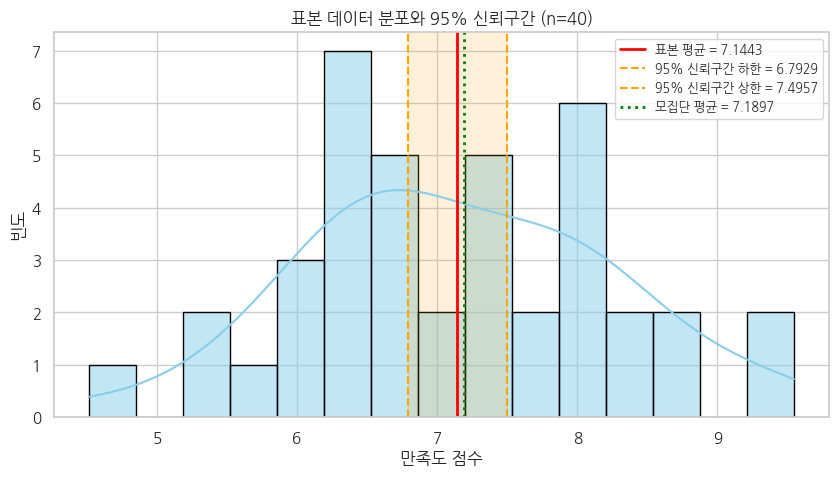

In [ ]:
# [문제 5] Q3. 표본 데이터의 히스토그램을 그리고, 평균 및 신뢰구간을 함께 시각화해봅시다.

# 표본 데이터 히스토그램 + 평균 및 신뢰구간 시각화
plt.figure(figsize=(10, 5))

sns.histplot(sample, bins=15, kde=True, color='skyblue', edgecolor='black')

# 표본 평균선
plt.axvline(sample_mean, color='red', linestyle='-', linewidth=2,
            label=f'표본 평균 = {sample_mean:.4f}')

# 신뢰구간 표시 (하한/상한 경계선 + 구간 음영)
plt.axvline(ci_lower, color='orange', linestyle='--', linewidth=1.5,
            label=f'95% 신뢰구간 하한 = {ci_lower:.4f}')
plt.axvline(ci_upper, color='orange', linestyle='--', linewidth=1.5,
            label=f'95% 신뢰구간 상한 = {ci_upper:.4f}')
plt.axvspan(ci_lower, ci_upper, color='orange', alpha=0.15)

# 모집단 평균선 (참고용)
plt.axvline(population.mean(), color='green', linestyle=':', linewidth=2,
            label=f'모집단 평균 = {population.mean():.4f}')

plt.title(f"표본 데이터 분포와 95% 신뢰구간 (n={sample_size})")
plt.xlabel("만족도 점수")
plt.ylabel("빈도")
plt.legend(fontsize=9)
plt.show()

## [문제 5] Q4 풀이 (실제 결과 반영) — 신뢰구간 기반 마케팅 전략

```
표본 평균: 7.1443
95% 신뢰구간: [6.7929, 7.4957]
구간 폭: 0.7028
모집단 평균(실제): 7.1897
```

**1. 목표 설정의 근거 자료로 활용**

이번 신뢰구간은 [6.79, 7.50]으로, 하한과 상한 모두 구체적인 숫자가 나왔습니다.
- **최소 보장선(하한 6.79)**: IR 자료나 대외 발표 시 "고객 만족도 최소 6.8점 이상 확보"처럼, 재조사해도 반박당하지 않을 **보수적 수치**로 제시할 수 있습니다.
- **목표선(상한 7.50)**: 다음 분기 목표를 "만족도 7.5점 달성"으로 잡으면 통계적 근거가 있는 도전 목표가 됩니다.

**2. 경쟁사 비교 시 오해 방지**

만약 경쟁사가 "만족도 7.3점"이라고 발표했다면, 우리 표본 평균(7.14)보다 높아 보이지만 7.3은 우리 신뢰구간 [6.79, 7.50] **안에 들어옵니다.** 즉 "경쟁사가 우리보다 통계적으로 유의미하게 앞선다"고 단정할 수 없다는 뜻입니다. 이는 성급한 할인 프로모션이나 방어적 마케팅 지출을 막아주는 근거 자료가 됩니다.

**3. 목표치와의 비교로 전략 방향 결정**

- 만약 회사 내부 목표가 **"7.0점 이상"**이었다면: 신뢰구간 하한(6.79)이 7.0보다 낮으므로, "목표 달성을 100% 확신할 수 없다"고 봐야 합니다 → 만족도 개선 캠페인을 유지/강화하는 것이 합리적입니다.
- 만약 목표가 **"6.5점 이상"**이었다면: 신뢰구간 전체가 6.5보다 위에 있으므로, "목표를 통계적으로 유의미하게 달성했다"고 자신 있게 발표할 수 있습니다 → 이 결과를 활용한 긍정적 브랜드 메시지(후기 마케팅, 신뢰도 강조 광고 등)를 진행할 수 있습니다.

**4. 표본 크기 확대 여부 판단**

이번 신뢰구간 폭은 **0.7028점**(7.4957 - 6.7929)입니다. 만약 마케팅팀이 0.2점 단위의 세밀한 차이(예: A/B 테스트로 캠페인 전후 만족도 비교)까지 검증해야 한다면, 이 정도 폭은 너무 넓어 판단이 어렵습니다.
→ [문제 3]에서 확인한 `SE = s/√n` 공식대로, 표본을 40명 → 약 160명(4배)으로 늘리면 폭을 절반 수준으로 줄일 수 있습니다. 세밀한 캠페인 효과 검증이 목적이라면 표본 확대에 투자할 가치가 있습니다.

**5. 보고서에 불확실성 명시**

"만족도 7.14점"이라는 단일 숫자 대신, "만족도는 95% 신뢰수준에서 6.79~7.50점 사이"라고 함께 보고하면, 경영진이 이 수치의 신뢰도와 한계(약 ±0.35점의 오차범위가 있다는 점)를 정확히 인지한 상태에서 의사결정을 내릴 수 있습니다.


## [문제 5] 데이터 해석

**Q. 신뢰구간은 몇 점에서 몇 점 사이인가요?**

95% 신뢰구간은 **[6.7929, 7.4957]**입니다. 표본 평균(7.1443)을 중심으로 오차범위(Margin of Error) 0.3514만큼 양쪽으로 뻗어 있는 구간입니다. 즉 "이 조사 방식을 반복한다면, 95%의 경우에서 모집단 평균이 대략 6.79점~7.50점 사이에 있을 것"이라고 해석할 수 있습니다.

**Q. 이 구간은 전체 모집단 평균을 포함하고 있나요?**

네, 포함합니다. 실제 모집단 평균은 **7.1897**이고, 이는 신뢰구간 [6.7929, 7.4957] 안에 들어옵니다(`True`). 그래프에서도 초록 점선(모집단 평균)이 주황 음영(신뢰구간) 안에, 그것도 빨간 실선(표본 평균)과 매우 가깝게 위치한 것을 볼 수 있습니다. 이번 표본이 모평균을 정확하게 잘 추정한 사례입니다.

**Q. 이 결과를 바탕으로 고객 만족도가 충분히 높다고 말할 수 있을까요?**

이 질문에 답하려면 "충분히 높다"의 **기준(benchmark)**이 먼저 필요합니다.

- 만약 회사의 목표가 "만족도 7.0점 이상"이었다면, 신뢰구간 [6.79, 7.50]의 하한이 7.0보다 낮으므로 "목표를 달성했다고 100% 확신할 수는 없다"고 봐야 합니다. 즉 통계적으로는 아직 목표 미달 가능성도 배제할 수 없는 상태입니다.
- 반면 목표가 "만족도 6.5점 이상"이었다면, 신뢰구간 전체(하한 6.79부터)가 6.5보다 위에 있으므로 "목표를 통계적으로 유의미하게 달성했다"고 자신 있게 말할 수 있습니다.

즉 표본 평균 7.14라는 숫자 하나만 보고 "높다/낮다"를 판단하기보다, **신뢰구간과 비교 기준(목표치, 작년 수치, 경쟁사 수치 등)을 함께 놓고 판단**해야 정확합니다.

**Q. 만약 신뢰구간이 너무 넓게 나왔다면, 그 이유는 무엇이고 어떻게 개선할 수 있을까요?**

이번 결과([문제 3]에서 확인한 표준오차(Standard Error, SE) 공식 `SE = σ/√n`을 떠올려보면) 신뢰구간의 폭은 다음 요인들에 좌우됩니다.
실제로는 σ 대신 표본표준편차 s를 사용해 추정: SE = s / √n

1. **표본 내 데이터의 변동성(표본표준편차)이 클 때** — 고객들의 만족도 응답이 들쭉날쭉할수록(예: 어떤 고객은 3점, 어떤 고객은 10점) 표본표준편차가 커지고, 그만큼 SE와 신뢰구간도 넓어집니다.
   → 개선책: 응답의 변동성이 큰 세그먼트를 별도로 나눠서(연령대별, 상품별 등) 조사하면, 그룹 내 변동성이 줄어 신뢰구간이 좁아질 수 있습니다.

2. **표본 크기(n)가 작을 때** — 이번 예시는 n=40인데, [문제 3]에서 확인했듯 n을 늘리면 SE는 σ/√n 공식에 따라 줄어듭니다.
   → 개선책: 설문 대상을 40명 → 100명, 400명 등으로 늘리면 신뢰구간을 눈에 띄게 좁힐 수 있습니다(다만 √n 관계이므로, 폭을 절반으로 줄이려면 표본은 4배로 늘려야 합니다).

3. **신뢰수준을 너무 높게 설정했을 때** — [문제 4]에서 봤듯 99% 신뢰수준은 95%보다 구간이 훨씬 넓습니다.
   → 개선책: 목적에 맞게 신뢰수준을 조정합니다(정밀한 비교가 목적이면 90%도 고려, 리스크가 큰 의사결정이면 99% 유지).

정리하면, **표본 크기를 늘리는 것이 가장 확실하고 통계적으로 정당한 개선 방법**이며, 조사 대상을 더 동질적인 그룹으로 나누는 것도 변동성을 줄여 신뢰구간을 좁히는 데 도움이 됩니다.